**Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Data Gathering

**A. Data Gathering**

In [3]:
mounting_drive = '/content/drive'
drive.mount(mounting_drive)

Mounted at /content/drive


**B. Load Dataset**

In [4]:
file_path = '/content/drive/MyDrive/Collage/Smstr 3/male_players.csv'
df = pd.read_csv(file_path)
df

,Unnamed: 0.1,Unnamed: 0,Rank,Name,OVR,PAC,SHO,PAS,DRI,DEF,...,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes
0,0,0,1,Kylian Mbappé,91,97,90,80,92,36,...,France,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Acrobatic, Finesse Shot, Flair, R...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
1,1,1,2,Rodri,91,66,80,86,84,87,...,Spain,Premier League,Manchester City,"Tiki Taka+, Aerial, Bruiser, Long Ball Pass, P...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
2,2,2,4,Erling Haaland,91,88,92,70,81,45,...,Norway,Premier League,Manchester City,"Acrobatic+, Bruiser, Power Header, Power Shot,...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
3,3,3,5,Jude Bellingham,90,80,87,83,88,78,...,England,LALIGA EA SPORTS,Real Madrid,"Relentless+, Flair, Intercept, Slide Tackle, T...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
4,4,4,7,Vini Jr.,90,95,84,81,91,29,...,Brazil,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Chip Shot, Finesse Shot, First To...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16156,16156,16156,17717,Engson Singh,47,31,45,47,52,34,...,India,ISL,Mohun Bagan SG,NaN,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
16157,16157,16157,17717,Ousmane Sylla,47,67,38,46,45,40,...,Senegal,MLS,Houston Dynamo,NaN,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
16158,16158,16158,17717,Wei Feng,47,57,47,38,50,43,...,China PR,CSL,Changchun Yatai,NaN,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
16159,16159,16159,17717,Won Hui Do,47,66,35,46,46,41,...,Korea Republic,K League 1,Jeju United,NaN,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN


In [5]:
# Tampilkan informasi dasar
print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"\nTipe data:\n{df.dtypes.value_counts()}")

# Lihat 5 data pertama
print("\n" + "=" * 60)
print("PREVIEW DATA")
print("=" * 60)
df.head()

INFORMASI DATASET
Jumlah baris: 16161
Jumlah kolom: 58

Tipe data:
int64      42
object     11
float64     5
Name: count, dtype: int64

PREVIEW DATA


,Unnamed: 0.1,Unnamed: 0,Rank,Name,OVR,PAC,SHO,PAS,DRI,DEF,...,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes
0,0,0,1,Kylian Mbappé,91,97,90,80,92,36,...,France,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Acrobatic, Finesse Shot, Flair, R...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
1,1,1,2,Rodri,91,66,80,86,84,87,...,Spain,Premier League,Manchester City,"Tiki Taka+, Aerial, Bruiser, Long Ball Pass, P...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
2,2,2,4,Erling Haaland,91,88,92,70,81,45,...,Norway,Premier League,Manchester City,"Acrobatic+, Bruiser, Power Header, Power Shot,...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
3,3,3,5,Jude Bellingham,90,80,87,83,88,78,...,England,LALIGA EA SPORTS,Real Madrid,"Relentless+, Flair, Intercept, Slide Tackle, T...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
4,4,4,7,Vini Jr.,90,95,84,81,91,29,...,Brazil,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Chip Shot, Finesse Shot, First To...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN


**C. Exploratory**

In [6]:
# Statistik deskriptif
print("=" * 60)
print("STATISTIK DESKRIPTIF")
print("=" * 60)
df.describe()

STATISTIK DESKRIPTIF


,Unnamed: 0.1,Unnamed: 0,Rank,OVR,PAC,SHO,PAS,DRI,DEF,PHY,...,Strength,Aggression,Weak foot,Skill moves,Age,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes
count,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,...,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,1816.000000,1816.000000,1816.000000,1816.000000,1816.000000
mean,8080.000000,8080.000000,8934.139657,66.172390,68.149558,54.146835,58.434874,63.599158,50.591981,65.241755,...,65.317121,56.342986,2.952045,2.393292,25.790545,65.282489,63.281388,62.361784,63.645925,66.120595
std,4665.423186,4665.423186,5003.925857,6.761979,10.612153,13.740389,9.660646,9.262399,16.323879,9.509657,...,12.370667,16.771384,0.677057,0.783739,4.662681,7.351546,7.019344,7.403049,8.026517,7.775521
min,0.000000,0.000000,1.000000,47.000000,29.000000,20.000000,25.000000,29.000000,15.000000,32.000000,...,26.000000,11.000000,1.000000,1.000000,17.000000,45.000000,45.000000,44.000000,41.000000,45.000000
25%,4040.000000,4040.000000,5037.000000,62.000000,62.000000,45.000000,52.000000,58.000000,36.000000,59.000000,...,58.000000,46.000000,3.000000,2.000000,22.000000,60.000000,58.000000,57.000000,58.000000,61.000000
50%,8080.000000,8080.000000,9009.000000,66.000000,69.000000,57.000000,59.000000,64.000000,55.000000,66.000000,...,66.000000,60.000000,3.000000,2.000000,25.000000,65.000000,63.000000,62.000000,64.000000,66.000000
75%,12120.000000,12120.000000,13135.000000,70.000000,75.000000,64.000000,65.000000,70.000000,64.000000,72.000000,...,74.000000,69.000000,3.000000,3.000000,29.000000,70.000000,68.000000,67.000000,69.000000,71.000000
max,16160.000000,16160.000000,17717.000000,91.000000,97.000000,93.000000,94.000000,92.000000,89.000000,91.000000,...,95.000000,95.000000,5.000000,5.000000,44.000000,90.000000,90.000000,91.000000,90.000000,91.000000


In [7]:
# Cek missing values
print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False))


MISSING VALUES
                       Missing Count  Percentage
GK Diving                      14345   88.763072
GK Kicking                     14345   88.763072
GK Handling                    14345   88.763072
GK Positioning                 14345   88.763072
GK Reflexes                    14345   88.763072
play style                      8682   53.721923
Alternative positions           7247   44.842522


In [8]:
# Distribusi posisi pemain
print("\n" + "=" * 60)
print("DISTRIBUSI POSISI PEMAIN")
print("=" * 60)
print(df['Position'].value_counts()) # Mengganti 'Positions' dengan 'Position'


DISTRIBUSI POSISI PEMAIN
Position
CB     2924
ST     2183
CM     1890
GK     1816
CDM    1330
RB     1281
LB     1214
LM      968
CAM     961
RM      896
RW      357
LW      341
Name: count, dtype: int64


# Data Preprocessing

**A. Data Cleaning**

1. Seleksi Kolom yang Relevan

In [9]:
columns_to_keep = [
    # Identitas
    'Name', 'Age', 'Height', 'Weight', 'Nation',

    # Target variable
    'Position', # Changed from 'Positions' to 'Position'

    # Atribut utama (Overall rating)
    'OVR',

    # Atribut kinerja (pace, shooting, passing, dribbling, defending, physical)
    'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY',

    # Sub-atribut detail (opsional, pilih sesuai kebutuhan)
    'Acceleration', 'Sprint Speed',  # Pace
    'Positioning', 'Finishing', 'Shot Power', 'Long Shots',  # Shooting
    'Vision', 'Crossing', 'Short Passing', 'Long Passing',  # Passing
    'Agility', 'Balance', 'Ball Control', 'Dribbling',  # Dribbling
    'Interceptions', 'Heading Accuracy', 'Def Awareness', 'Standing Tackle', 'Sliding Tackle',  # Defending
    'Jumping', 'Stamina', 'Strength', 'Aggression',  # Physical

    # GK-related attributes
    'GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning', 'GK Reflexes'
]

# Filter columns that are actually present in the dataframe
available_columns = [col for col in columns_to_keep if col in df.columns]
df_clean = df[available_columns].copy()

print(f"Updated columns to keep: {len(available_columns)}")
print(f"Shape of df_clean after update: {df_clean.shape}")
print("First 5 rows of the updated df_clean:")
print(df_clean.head())

Updated columns to keep: 41
Shape of df_clean after update: (16161, 41)
First 5 rows of the updated df_clean:
              Name  Age        Height        Weight   Nation Position  OVR  \
0    Kylian Mbappé   25  182cm / 6'0"  75kg / 165lb   France       ST   91   
1            Rodri   28  191cm / 6'3"  82kg / 181lb    Spain      CDM   91   
2   Erling Haaland   24  195cm / 6'5"  94kg / 207lb   Norway       ST   91   
3  Jude Bellingham   21  186cm / 6'1"  75kg / 165lb  England      CAM   90   
4         Vini Jr.   24  176cm / 5'9"  73kg / 161lb   Brazil       LW   90   

   PAC  SHO  PAS  ...  Sliding Tackle  Jumping  Stamina  Strength  Aggression  \
0   97   90   80  ...              32       88       88        77          64   
1   66   80   86  ...              82       83       91        83          85   
2   88   92   70  ...              29       92       76        93          88   
3   80   87   83  ...              77       84       93        77          85   
4   95   84   81

In [ ]:
gk_columns = ['GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning', 'GK Reflexes']
for col in gk_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

print("NaN values in GK columns filled with 0.")
print("First 5 rows of df_clean after filling NaN in GK columns:")
print(df_clean[gk_columns].head())

NaN values in GK columns filled with 0.
First 5 rows of df_clean after filling NaN in GK columns:
   GK Diving  GK Handling  GK Kicking  GK Positioning  GK Reflexes
0        0.0          0.0         0.0             0.0          0.0
1        0.0          0.0         0.0             0.0          0.0
2        0.0          0.0         0.0             0.0          0.0
3        0.0          0.0         0.0             0.0          0.0
4        0.0          0.0         0.0             0.0          0.0


In [11]:
# Filter kolom yang ada di dataset
available_columns = [col for col in columns_to_keep if col in df.columns]
df_clean = df[available_columns].copy()

print(f"Kolom yang digunakan: {len(available_columns)}")
print(f"Shape data: {df_clean.shape}")

Kolom yang digunakan: 41
Shape data: (16161, 41)


2. Handling Missing Values

In [12]:
# Strategi 1: Hapus baris dengan missing values > 50%
threshold = 0.5
missing_ratio = df_clean.isnull().sum(axis=1) / df_clean.shape[1]
df_clean = df_clean[missing_ratio < threshold]

print(f"Data setelah filtering: {df_clean.shape}")

Data setelah filtering: (16161, 41)


In [13]:
# Strategi 2: Imputasi untuk kolom numerik
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        # Gunakan median untuk robustness terhadap outlier
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

In [14]:
# Strategi 3: Hapus baris dengan missing values di kolom penting
df_clean = df_clean.dropna(subset=['Position', 'OVR'])

print(f"Data setelah handling missing values: {df_clean.shape}")
print(f"Missing values tersisa: {df_clean.isnull().sum().sum()}")

Data setelah handling missing values: (16161, 41)
Missing values tersisa: 0


3. Kategorisasi Posisi

In [15]:
# Fungsi untuk kategorisasi posisi
def categorize_position(position):
    """
    Kategorisasi posisi pemain menjadi 4 kategori utama:
    - GK: Goalkeeper
    - DF: Defender (CB, LB, RB)
    - MF: Midfielder (CDM, CM, CAM, LM, RM)
    - FW: Forward (ST, CF, LW, RW)
    """
    if pd.isna(position):
        return 'Unknown'

    position = str(position).upper()

    # Goalkeeper
    if 'GK' in position:
        return 'GK'

    # Defender
    elif any(pos in position for pos in ['CB', 'LB', 'RB']):
        return 'DF'

    # Midfielder
    elif any(pos in position for pos in ['CDM', 'CM', 'CAM', 'LM', 'RM']):
        return 'MF'

    # Forward
    elif any(pos in position for pos in ['ST', 'LW', 'RW']):
        return 'FW'

    else:
        return 'Unknown'

In [16]:
# Terapkan kategorisasi
df_clean['position_category'] = df_clean['Position'].apply(categorize_position)

# Hapus kategori 'Unknown'
df_clean = df_clean[df_clean['position_category'] != 'Unknown']

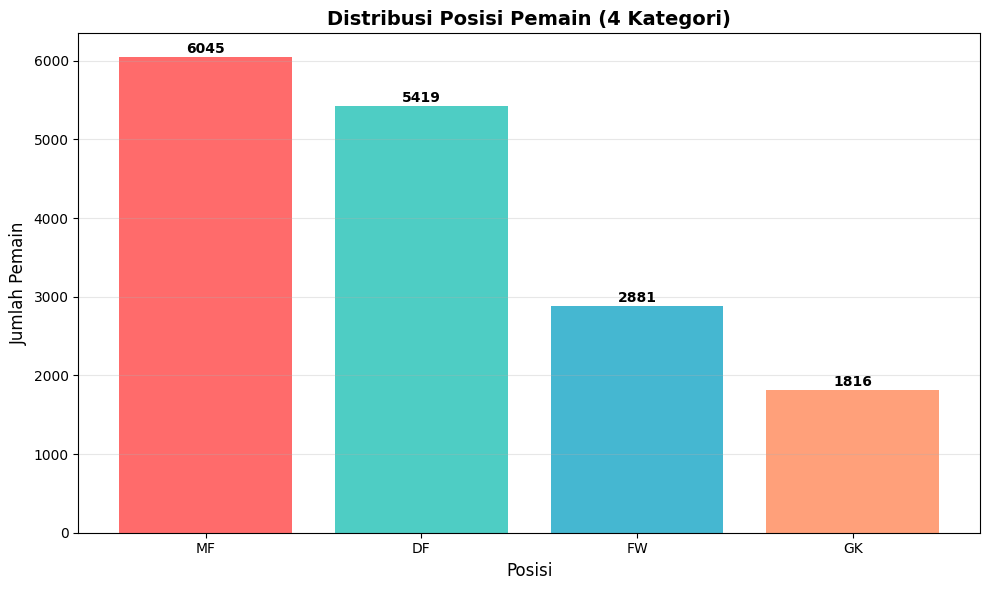


Distribusi Posisi:
position_category
MF    6045
DF    5419
FW    2881
GK    1816
Name: count, dtype: int64

Total pemain: 16161


In [17]:
# Visualisasi distribusi
plt.figure(figsize=(10, 6))
position_counts = df_clean['position_category'].value_counts()
plt.bar(position_counts.index, position_counts.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
plt.title('Distribusi Posisi Pemain (4 Kategori)', fontsize=14, fontweight='bold')
plt.xlabel('Posisi', fontsize=12)
plt.ylabel('Jumlah Pemain', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Tambahkan label jumlah
for i, v in enumerate(position_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nDistribusi Posisi:")
print(position_counts)
print(f"\nTotal pemain: {len(df_clean)}")

4. Deteksi dan Handling Outliers

In [18]:
# Fungsi untuk deteksi outlier menggunakan IQR
def detect_outliers_IQR(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    return outliers, lower_bound, upper_bound

In [19]:
# Pilih kolom numerik untuk deteksi outlier
numeric_features = ['PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY']

print("=" * 60)
print("DETEKSI OUTLIERS")
print("=" * 60)

for col in numeric_features:
    if col in df_clean.columns:
        outliers, lb, ub = detect_outliers_IQR(df_clean, col)
        print(f"\n{col}:")
        print(f"  Lower Bound: {lb:.2f}")
        print(f"  Upper Bound: {ub:.2f}")
        print(f"  Outliers: {len(outliers)} ({len(outliers)/len(df_clean)*100:.2f}%)")

DETEKSI OUTLIERS

PAC:
  Lower Bound: 42.50
  Upper Bound: 94.50
  Outliers: 318 (1.97%)

SHO:
  Lower Bound: 16.50
  Upper Bound: 92.50
  Outliers: 1 (0.01%)

PAS:
  Lower Bound: 32.50
  Upper Bound: 84.50
  Outliers: 134 (0.83%)

DRI:
  Lower Bound: 40.00
  Upper Bound: 88.00
  Outliers: 236 (1.46%)

DEF:
  Lower Bound: -6.00
  Upper Bound: 106.00
  Outliers: 0 (0.00%)

PHY:
  Lower Bound: 39.50
  Upper Bound: 91.50
  Outliers: 102 (0.63%)


In [20]:
# Strategi: Capping (membatasi nilai outlier)
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

In [21]:
# Terapkan capping untuk outlier ekstrem
for col in numeric_features:
    if col in df_clean.columns:
        df_clean = cap_outliers(df_clean, col)

print("\n✓ Outliers telah di-handle menggunakan capping method")


✓ Outliers telah di-handle menggunakan capping method


**B. Feature Selection**

1. Correlation Analysis

In [22]:
# Pilih fitur numerik
numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('OVR') if 'OVR' in numeric_features else None

# Encode target variable untuk korelasi
le = LabelEncoder()
df_clean['position_encoded'] = le.fit_transform(df_clean['position_category'])

In [23]:
# Hitung korelasi dengan target
correlation_with_target = df_clean[numeric_features + ['position_encoded']].corr()['position_encoded'].abs().sort_values(ascending=False)

print("=" * 60)
print("KORELASI FITUR DENGAN POSISI PEMAIN")
print("=" * 60)
print(correlation_with_target[1:15])  # Top 15 fitur


KORELASI FITUR DENGAN POSISI PEMAIN
SHO                 0.480236
PAS                 0.423301
Vision              0.414626
DRI                 0.408865
Jumping             0.347533
Strength            0.341859
Heading Accuracy    0.328197
Shot Power          0.303373
Long Shots          0.275479
Finishing           0.265593
PHY                 0.260970
Sliding Tackle      0.248962
Def Awareness       0.245124
DEF                 0.244937
Name: position_encoded, dtype: float64


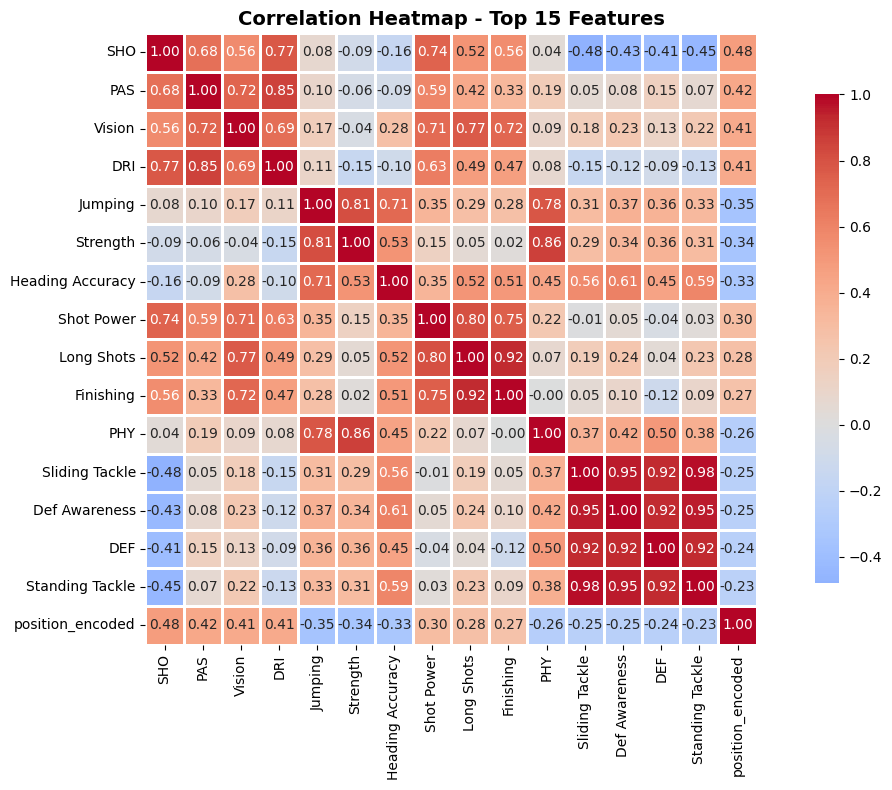

In [24]:
# Visualisasi korelasi
plt.figure(figsize=(12, 8))
top_features = correlation_with_target[1:16].index.tolist()
correlation_matrix = df_clean[top_features + ['position_encoded']].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Top 15 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

2. Feature Importance

In [25]:
# Gunakan Decision Tree sederhana untuk melihat feature importance awal
from sklearn.tree import DecisionTreeClassifier

# Pisahkan fitur dan target
X_temp = df_clean[numeric_features]
y_temp = df_clean['position_category']

# Train decision tree sederhana
dt_temp = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_temp.fit(X_temp, y_temp)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [26]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': numeric_features,
    'Importance': dt_temp.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE (Preliminary)")
print("=" * 60)
print(feature_importance.head(15))


FEATURE IMPORTANCE (Preliminary)
             Feature  Importance
25    Sliding Tackle    0.312921
9        Positioning    0.261633
13            Vision    0.203691
22  Heading Accuracy    0.103755
16      Long Passing    0.036163
14          Crossing    0.033948
12        Long Shots    0.013236
8       Sprint Speed    0.010098
5                DEF    0.007995
23     Def Awareness    0.007295
28          Strength    0.004794
10         Finishing    0.004211
11        Shot Power    0.000261
0                Age    0.000000
1                PAC    0.000000


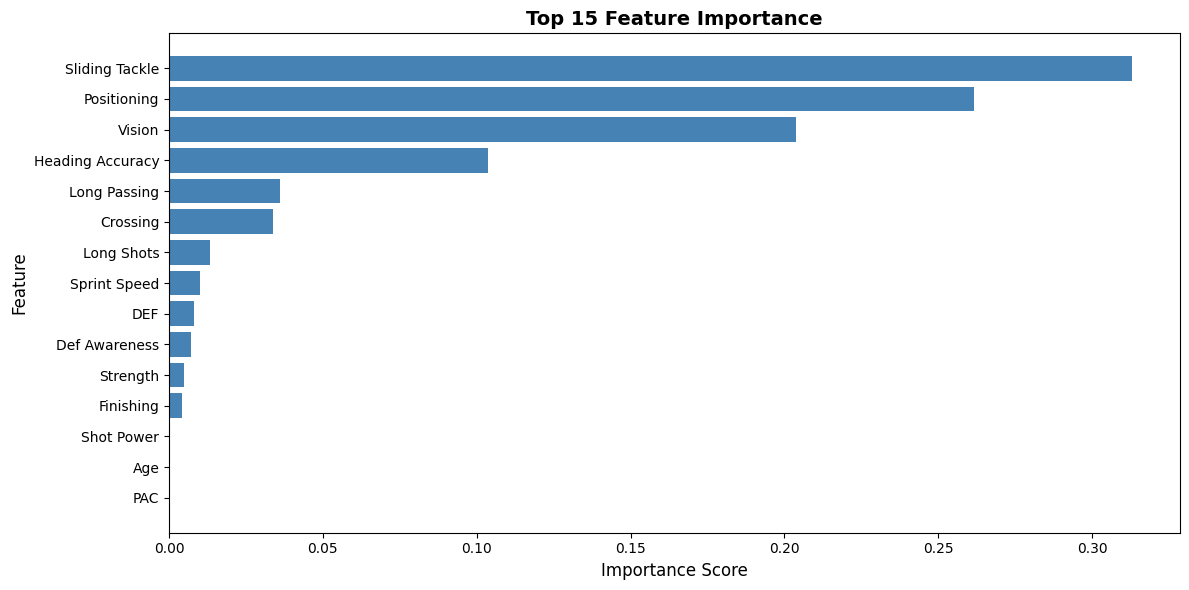

In [27]:
# Visualisasi
plt.figure(figsize=(12, 6))
top_15_features = feature_importance.head(15)
plt.barh(top_15_features['Feature'], top_15_features['Importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 15 Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**C. Feature Engineering**

1. Aggregate Features

In [28]:
# Buat fitur agregat baru
print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# Attack Score (rata-rata shooting, passing, dribbling)
if all(col in df_clean.columns for col in ['SHO', 'PAS', 'DRI']):
    df_clean['attack_score'] = df_clean[['SHO', 'PAS', 'DRI']].mean(axis=1)
    print("✓ Created: attack_score")

# Defense Score (rata-rata defending, physical)
if all(col in df_clean.columns for col in ['DEF', 'PHY']):
    df_clean['defense_score'] = df_clean[['DEF', 'PHY']].mean(axis=1)
    print("✓ Created: defense_score")

# Total Technical Score
if all(col in df_clean.columns for col in ['SHO', 'PAS', 'DRI']):
    df_clean['technical_score'] = df_clean[['SHO', 'PAS', 'DRI']].sum(axis=1)
    print("✓ Created: technical_score")

# Physical Dominance (strength + aggression)
if all(col in df_clean.columns for col in ['Strength', 'Aggression']):
    df_clean['physical_dominance'] = df_clean[['Strength', 'Aggression']].mean(axis=1)
    print("✓ Created: physical_dominance")

FEATURE ENGINEERING
✓ Created: attack_score
✓ Created: defense_score
✓ Created: technical_score
✓ Created: physical_dominance


2. Ratio Features

In [29]:
# Attack-Defense Ratio
if all(col in df_clean.columns for col in ['attack_score', 'defense_score']):
    df_clean['attack_defense_ratio'] = df_clean['attack_score'] / (df_clean['defense_score'] + 1)
    print("✓ Created: attack_defense_ratio")

# Pace-Physical Ratio
if all(col in df_clean.columns for col in ['pace', 'physic']):
    df_clean['pace_physical_ratio'] = df_clean['pace'] / (df_clean['physic'] + 1)
    print("✓ Created: pace_physical_ratio")

# Shooting Efficiency (shooting per age - younger with high shooting = talented)
if all(col in df_clean.columns for col in ['shooting', 'age']):
    df_clean['shooting_efficiency'] = df_clean['shooting'] / df_clean['age']
    print("✓ Created: shooting_efficiency")

print(f"\nTotal features setelah engineering: {df_clean.shape[1]}")

✓ Created: attack_defense_ratio

Total features setelah engineering: 48


**D. Data Transformation**

1. Normalisasi (Min-Max Scalling)

In [30]:
# Pilih fitur numerik untuk normalisasi (exclude encoded target)
features_to_scale = df_clean.select_dtypes(include=[np.number]).columns.tolist()
features_to_scale = [f for f in features_to_scale if f not in ['position_encoded']]

# Simpan data sebelum scaling untuk referensi
df_before_scaling = df_clean.copy()

# Inisialisasi scaler
scaler = MinMaxScaler()

# Lakukan scaling
df_clean[features_to_scale] = scaler.fit_transform(df_clean[features_to_scale])

print("=" * 60)
print("NORMALISASI DATA (MIN-MAX SCALING)")
print("=" * 60)
print(f"Jumlah fitur yang di-scale: {len(features_to_scale)}")
print(f"\nRentang nilai setelah scaling: [0, 1]")

NORMALISASI DATA (MIN-MAX SCALING)
Jumlah fitur yang di-scale: 41

Rentang nilai setelah scaling: [0, 1]


In [31]:
# Perbandingan sebelum dan sesudah
print("\nContoh perbandingan (5 fitur pertama):")
comparison_features = features_to_scale[:5]
comparison_df = pd.DataFrame({
    'Feature': comparison_features,
    'Before (Mean)': [df_before_scaling[f].mean() for f in comparison_features],
    'After (Mean)': [df_clean[f].mean() for f in comparison_features],
    'Before (Std)': [df_before_scaling[f].std() for f in comparison_features],
    'After (Std)': [df_clean[f].std() for f in comparison_features]
})
print(comparison_df.to_string(index=False))


Contoh perbandingan (5 fitur pertama):
Feature  Before (Mean)  After (Mean)  Before (Std)  After (Std)
    Age      25.790545      0.325576      4.662681     0.172692
    OVR      66.172390      0.435736      6.761979     0.153681
    PAC      68.262112      0.495425     10.289691     0.197879
    SHO      54.146804      0.470990     13.740303     0.189521
    PAS      58.443908      0.498921      9.601819     0.184650


**E. Data Splitting**

1. Straitified Split

In [32]:
# Definisikan fitur (X) dan target (y)
# Pilih fitur terbaik berdasarkan feature importance atau semua fitur
selected_features = [
    'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY',
    'attack_score', 'defense_score', 'attack_defense_ratio'
]

# Filter fitur yang tersedia
selected_features = [f for f in selected_features if f in df_clean.columns]

X = df_clean[selected_features]
y = df_clean['position_category']

print("=" * 60)
print("DATA SPLITTING")
print("=" * 60)
print(f"Total features: {len(selected_features)}")
print(f"Features: {selected_features}")
print(f"\nDataset shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

DATA SPLITTING
Total features: 9
Features: ['PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'attack_score', 'defense_score', 'attack_defense_ratio']

Dataset shape: (16161, 9)
Target distribution:
position_category
MF    6045
DF    5419
FW    2881
GK    1816
Name: count, dtype: int64


In [33]:
# Split dengan stratified sampling (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Memastikan distribusi kelas seimbang
)

print(f"\n" + "=" * 60)
print("HASIL SPLIT")
print("=" * 60)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nDistribusi kelas di Training set:")
print(y_train.value_counts())
print(f"\nDistribusi kelas di Testing set:")
print(y_test.value_counts())


HASIL SPLIT
Training set: 12928 samples (80.0%)
Testing set: 3233 samples (20.0%)

Distribusi kelas di Training set:
position_category
MF    4836
DF    4335
FW    2304
GK    1453
Name: count, dtype: int64

Distribusi kelas di Testing set:
position_category
MF    1209
DF    1084
FW     577
GK     363
Name: count, dtype: int64


# Model Development

**A. Baseline Model (Simple Decision Tree)**

In [34]:
print("=" * 60)
print("BASELINE MODEL - DECISION TREE")
print("=" * 60)

# Inisialisasi model baseline
dt_baseline = DecisionTreeClassifier(random_state=42)

# Training
dt_baseline.fit(X_train, y_train)

# Prediksi
y_pred_baseline = dt_baseline.predict(X_test)

# Evaluasi
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"\nBaseline Accuracy: {accuracy_baseline:.4f} ({accuracy_baseline*100:.2f}%)")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

BASELINE MODEL - DECISION TREE

Baseline Accuracy: 0.7532 (75.32%)

Classification Report:
              precision    recall  f1-score   support

          DF       0.84      0.83      0.83      1084
          FW       0.71      0.65      0.68       577
          GK       0.76      0.82      0.79       363
          MF       0.70      0.72      0.71      1209

    accuracy                           0.75      3233
   macro avg       0.75      0.75      0.75      3233
weighted avg       0.75      0.75      0.75      3233



**B. Hyperparameter Tuning dengan Grid Search**

In [35]:
print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING - GRID SEARCH")
print("=" * 60)

# Definisikan parameter grid
param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None]
}

# Inisialisasi Grid Search dengan Cross-Validation
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,  # Gunakan semua core CPU
    verbose=2
)

# Fitting (ini akan memakan waktu)
print("\n🔄 Melakukan Grid Search... (ini akan memakan waktu)")
grid_search.fit(X_train, y_train)

# Best parameters
print("\n" + "=" * 60)
print("HASIL GRID SEARCH")
print("=" * 60)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Model terbaik
best_dt = grid_search.best_estimator_


HYPERPARAMETER TUNING - GRID SEARCH

🔄 Melakukan Grid Search... (ini akan memakan waktu)
Fitting 5 folds for each of 480 candidates, totalling 2400 fits

HASIL GRID SEARCH
Best parameters: {'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 20}
Best cross-validation score: 0.7806


**C. Hasil Evaluation (Final Model)**

In [36]:
print("\n" + "=" * 60)
print("EVALUASI MODEL FINAL")
print("=" * 60)

# Prediksi dengan model terbaik
y_pred_final = best_dt.predict(X_test)

# Metrik evaluasi
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final, average='weighted')
recall_final = recall_score(y_test, y_pred_final, average='weighted')
f1_final = f1_score(y_test, y_pred_final, average='weighted')

print(f"\n📊 METRIK EVALUASI:")
print(f"  Accuracy:  {accuracy_final:.4f} ({accuracy_final*100:.2f}%)")
print(f"  Precision: {precision_final:.4f}")
print(f"  Recall:    {recall_final:.4f}")
print(f"  F1-Score:  {f1_final:.4f}")

# Classification report per kelas
print(f"\n" + "=" * 60)
print("CLASSIFICATION REPORT PER POSISI")
print("=" * 60)
print(classification_report(y_test, y_pred_final))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
print(f"\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)
print(cm)


EVALUASI MODEL FINAL

📊 METRIK EVALUASI:
  Accuracy:  0.7776 (77.76%)
  Precision: 0.7797
  Recall:    0.7776
  F1-Score:  0.7770

CLASSIFICATION REPORT PER POSISI
              precision    recall  f1-score   support

          DF       0.87      0.84      0.86      1084
          FW       0.76      0.65      0.70       577
          GK       0.73      0.88      0.79       363
          MF       0.73      0.75      0.74      1209

    accuracy                           0.78      3233
   macro avg       0.77      0.78      0.77      3233
weighted avg       0.78      0.78      0.78      3233


CONFUSION MATRIX
[[915   2   0 167]
 [  2 376  53 146]
 [  1  17 318  27]
 [136 101  67 905]]


# Visualisasi Hasil

**A. Confusion Matrix Heatmap**

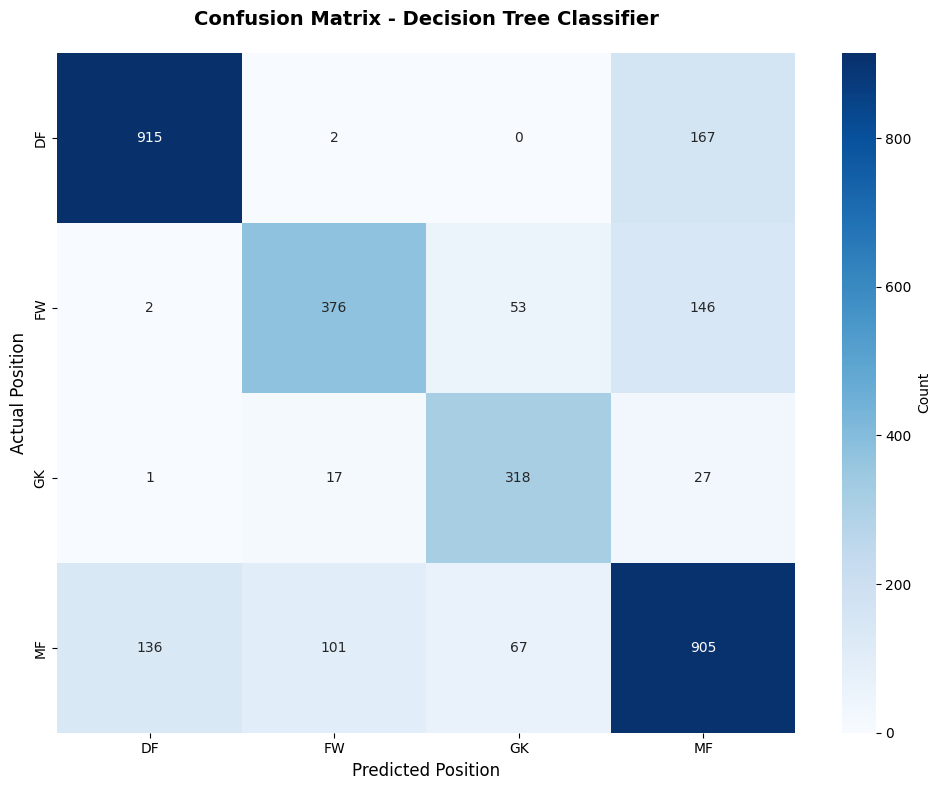

In [38]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_dt.classes_,
            yticklabels=best_dt.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Decision Tree Classifier', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Actual Position', fontsize=12)
plt.xlabel('Predicted Position', fontsize=12)
plt.tight_layout()
plt.show()

**B. Akurasi Per Posisi**


METRIK PER POSISI
Position  Precision   Recall  F1-Score  Support
      DF   0.868121 0.844096  0.855940     1084
      FW   0.758065 0.651646  0.700839      577
      GK   0.726027 0.876033  0.794007      363
      MF   0.726908 0.748553  0.737571     1209


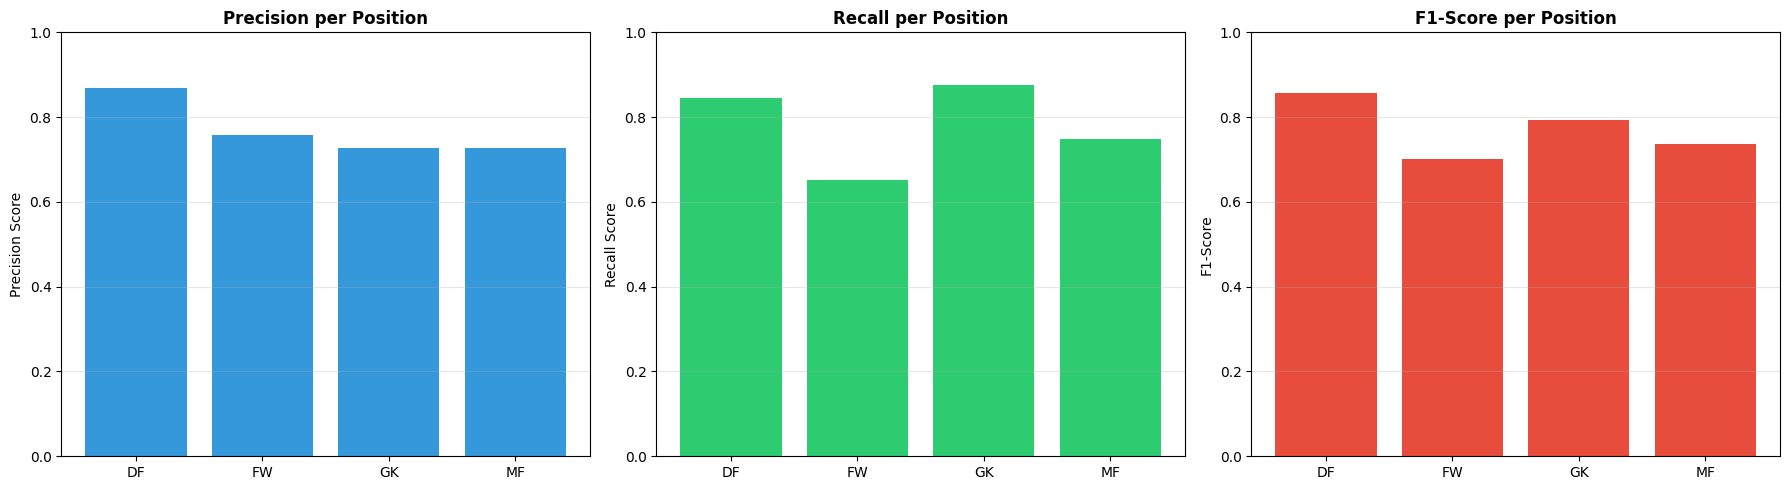

In [39]:
# Hitung akurasi per kelas
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred_final)

# Buat dataframe untuk visualisasi
metrics_df = pd.DataFrame({
    'Position': best_dt.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("\n" + "=" * 60)
print("METRIK PER POSISI")
print("=" * 60)
print(metrics_df.to_string(index=False))

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Precision
axes[0].bar(metrics_df['Position'], metrics_df['Precision'], color='#3498db')
axes[0].set_title('Precision per Position', fontweight='bold')
axes[0].set_ylabel('Precision Score')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Recall
axes[1].bar(metrics_df['Position'], metrics_df['Recall'], color='#2ecc71')
axes[1].set_title('Recall per Position', fontweight='bold')
axes[1].set_ylabel('Recall Score')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

# F1-Score
axes[2].bar(metrics_df['Position'], metrics_df['F1-Score'], color='#e74c3c')
axes[2].set_title('F1-Score per Position', fontweight='bold')
axes[2].set_ylabel('F1-Score')
axes[2].set_ylim([0, 1])
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**C. Feature Importance (Final)**


FEATURE IMPORTANCE (FINAL MODEL)
             Feature  Importance
attack_defense_ratio    0.505131
                 PAC    0.116413
                 DEF    0.114866
                 PHY    0.093261
                 PAS    0.071528
                 SHO    0.069534
                 DRI    0.012384
        attack_score    0.011279
       defense_score    0.005604


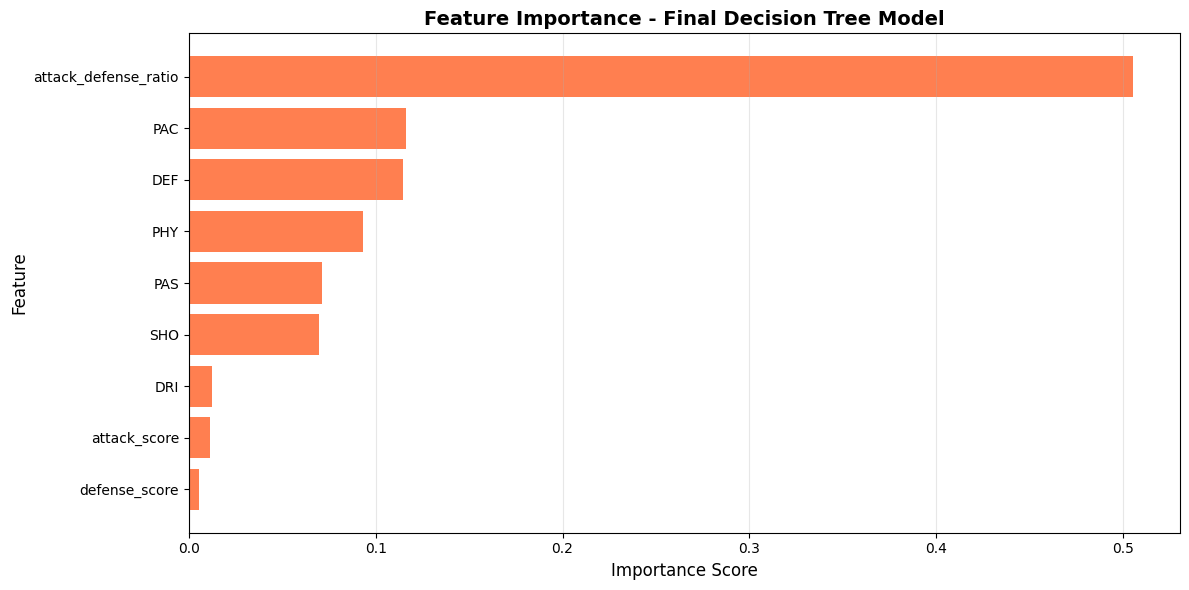

In [40]:
# Feature importance dari model final
feature_importance_final = pd.DataFrame({
    'Feature': selected_features,
    'Importance': best_dt.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE (FINAL MODEL)")
print("=" * 60)
print(feature_importance_final.to_string(index=False))

# Visualisasi
plt.figure(figsize=(12, 6))
plt.barh(feature_importance_final['Feature'], feature_importance_final['Importance'], color='coral')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance - Final Decision Tree Model', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**D. Decision Tree Visualization**

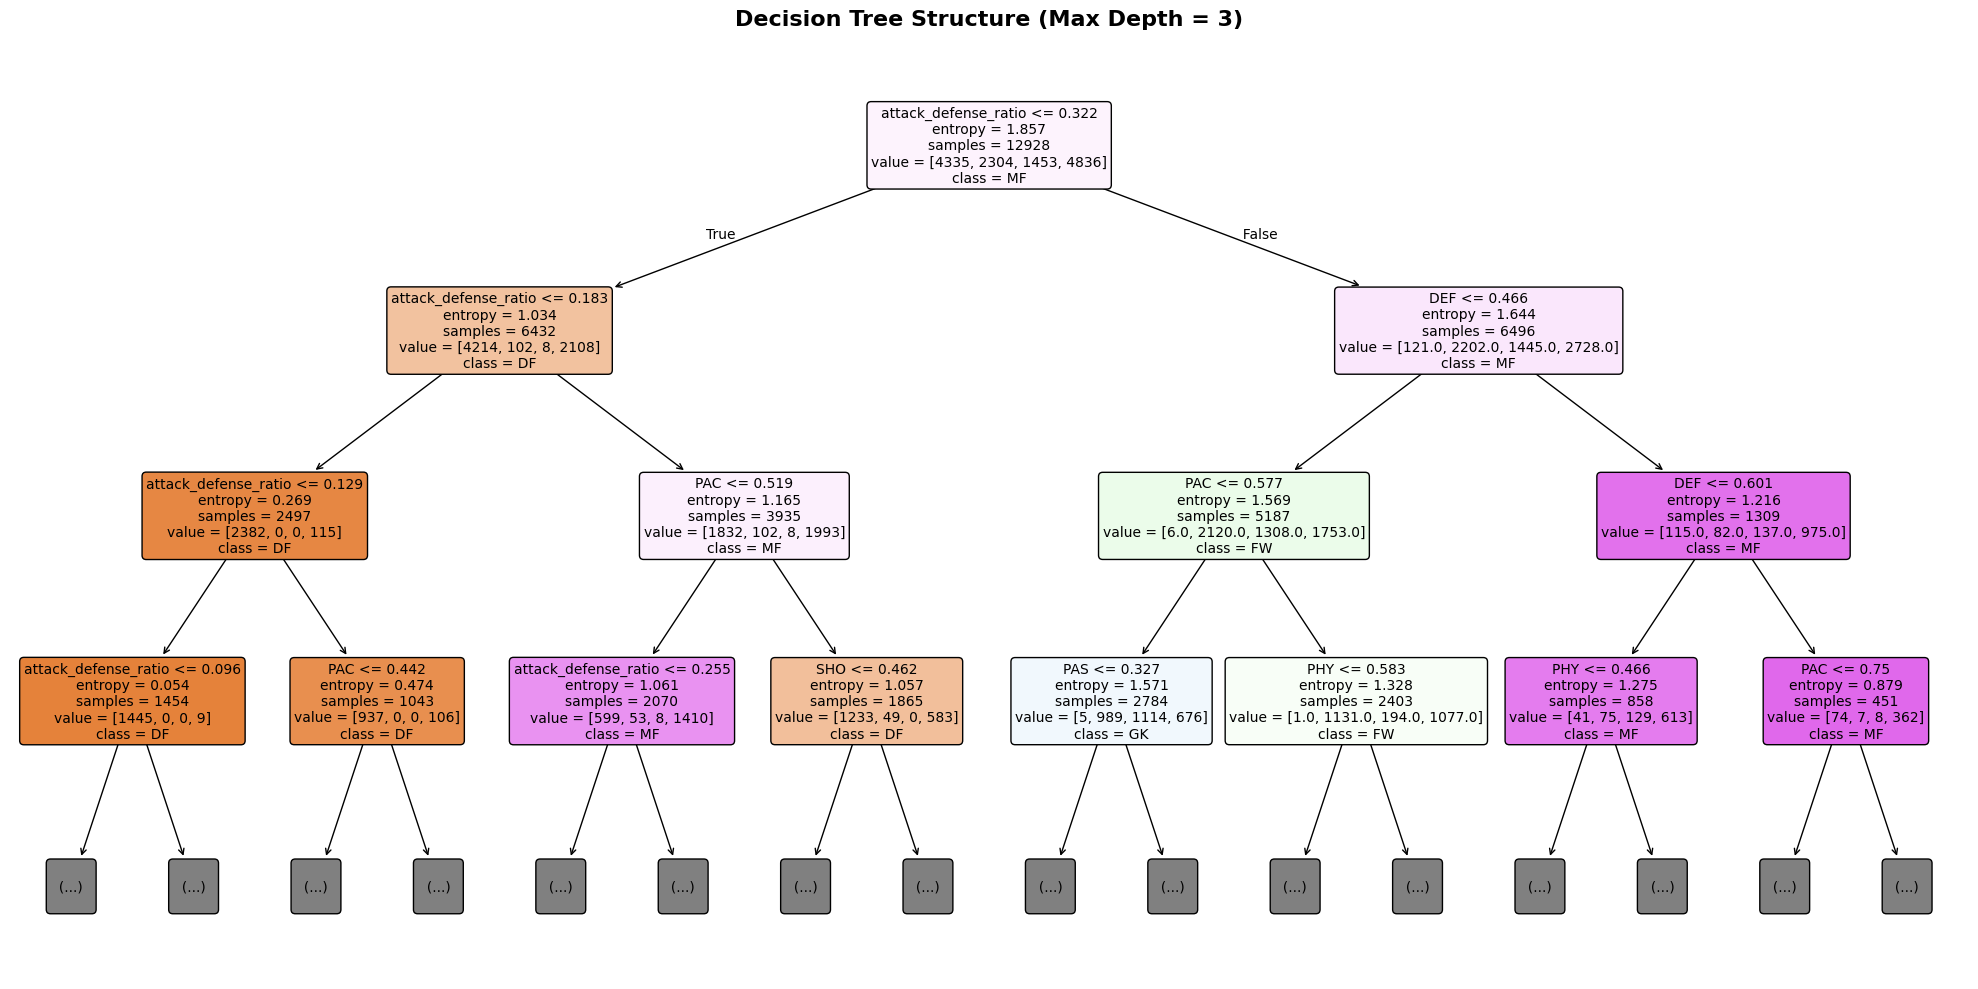

In [42]:
# Visualisasi pohon keputusan (simplified untuk keterbacaan)
plt.figure(figsize=(20, 10))
plot_tree(best_dt,
          max_depth=3,  # Batasi kedalaman untuk keterbacaan
          feature_names=selected_features,
          class_names=best_dt.classes_,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Structure (Max Depth = 3)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Cross-Validation


CROSS-VALIDATION (5-FOLD)

CV Scores: [0.76334107 0.78422274 0.7896365  0.78104449 0.78491296]
Mean CV Score: 0.7806
Std CV Score: 0.0091
CV Variance: 0.000082


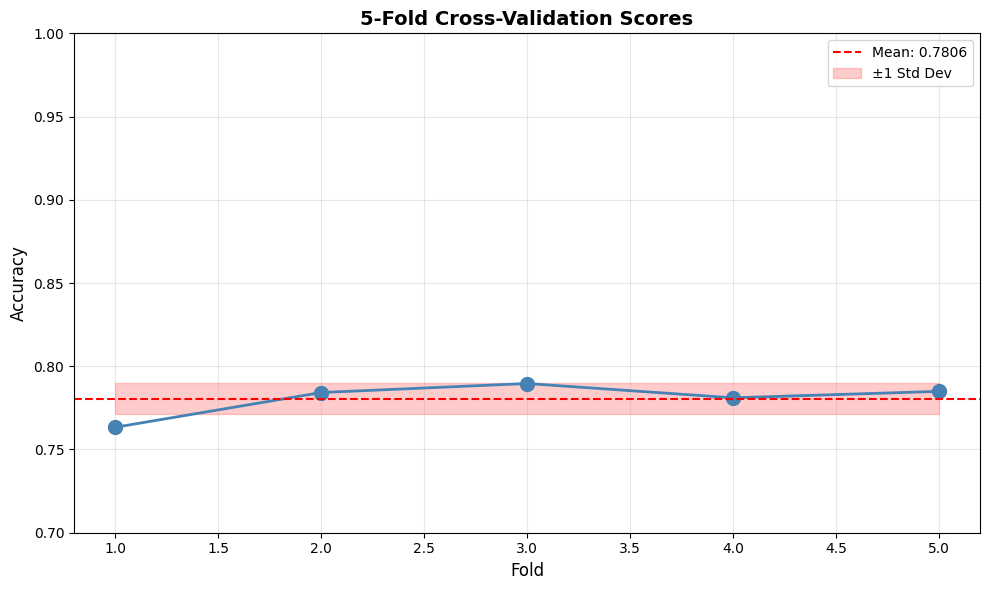

In [43]:
print("\n" + "=" * 60)
print("CROSS-VALIDATION (5-FOLD)")
print("=" * 60)

# Lakukan cross-validation
cv_scores = cross_val_score(best_dt, X_train, y_train, cv=5, scoring='accuracy')

print(f"\nCV Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f}")
print(f"Std CV Score: {cv_scores.std():.4f}")
print(f"CV Variance: {cv_scores.std()**2:.6f}")

# Visualisasi CV scores
plt.figure(figsize=(10, 6))
folds = range(1, 6)
plt.plot(folds, cv_scores, marker='o', linestyle='-', linewidth=2, markersize=10, color='steelblue')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.fill_between(folds,
                 cv_scores.mean() - cv_scores.std(),
                 cv_scores.mean() + cv_scores.std(),
                 alpha=0.2, color='red', label=f'±1 Std Dev')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('5-Fold Cross-Validation Scores', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim([0.7, 1.0])
plt.tight_layout()
plt.show()


# Perbandingan Skenario Pengujian

**A. Different Split Ratios**

In [44]:
print("\n" + "=" * 60)
print("SKENARIO 1: PERBANDINGAN SPLIT RATIO")
print("=" * 60)

split_ratios = [(0.7, 0.3), (0.8, 0.2), (0.9, 0.1)]
split_results = []

for train_size, test_size in split_ratios:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)

    dt_temp = DecisionTreeClassifier(**grid_search.best_params_, random_state=42)
    dt_temp.fit(X_tr, y_tr)
    y_pred_temp = dt_temp.predict(X_te)

    acc = accuracy_score(y_te, y_pred_temp)
    split_results.append({
        'Split Ratio': f'{int(train_size*100)}:{int(test_size*100)}',
        'Train Size': len(X_tr),
        'Test Size': len(X_te),
        'Accuracy': acc
    })

    print(f"Split {int(train_size*100)}:{int(test_size*100)} - Accuracy: {acc:.4f}")

split_df = pd.DataFrame(split_results)
print(f"\n{split_df.to_string(index=False)}")



SKENARIO 1: PERBANDINGAN SPLIT RATIO
Split 70:30 - Accuracy: 0.7890
Split 80:20 - Accuracy: 0.7776
Split 90:10 - Accuracy: 0.7805

Split Ratio  Train Size  Test Size  Accuracy
      70:30       11312       4849  0.789029
      80:20       12928       3233  0.777606
      90:10       14544       1617  0.780458


**B. Different Feature Sets**

In [45]:
print("\n" + "=" * 60)
print("SKENARIO 2: PERBANDINGAN FEATURE SETS")
print("=" * 60)

# Top-5 features
top5_features = feature_importance_final.head(5)['Feature'].tolist()
X_top5 = df_clean[top5_features]

# Top-10 features
top10_features = feature_importance_final.head(10)['Feature'].tolist()
X_top10 = df_clean[top10_features]

# All features
X_all = X

feature_sets = {
    'Top-5 Features': X_top5,
    'Top-10 Features': X_top10,
    'All Features': X_all
}

feature_results = []

for name, X_features in feature_sets.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X_features, y, test_size=0.2, random_state=42, stratify=y)

    dt_temp = DecisionTreeClassifier(**grid_search.best_params_, random_state=42)
    dt_temp.fit(X_tr, y_tr)
    y_pred_temp = dt_temp.predict(X_te)

    acc = accuracy_score(y_te, y_pred_temp)
    feature_results.append({
        'Feature Set': name,
        'Num Features': X_features.shape[1],
        'Accuracy': acc
    })

    print(f"{name} ({X_features.shape[1]} features) - Accuracy: {acc:.4f}")

feature_df = pd.DataFrame(feature_results)


SKENARIO 2: PERBANDINGAN FEATURE SETS
Top-5 Features (5 features) - Accuracy: 0.7773
Top-10 Features (9 features) - Accuracy: 0.7779
All Features (9 features) - Accuracy: 0.7776


**C. Criterion Comparison**

In [46]:
print("\n" + "=" * 60)
print("SKENARIO 3: PERBANDINGAN CRITERION")
print("=" * 60)

criterions = ['gini', 'entropy']
criterion_results = []

for criterion in criterions:
    dt_temp = DecisionTreeClassifier(criterion=criterion, **{k:v for k,v in grid_search.best_params_.items() if k != 'criterion'}, random_state=42)
    dt_temp.fit(X_train, y_train)
    y_pred_temp = dt_temp.predict(X_test)

    acc = accuracy_score(y_test, y_pred_temp)
    criterion_results.append({
        'Criterion': criterion.capitalize(),
        'Accuracy': acc
    })

    print(f"{criterion.capitalize()} - Accuracy: {acc:.4f}")

criterion_df = pd.DataFrame(criterion_results)


SKENARIO 3: PERBANDINGAN CRITERION
Gini - Accuracy: 0.7900
Entropy - Accuracy: 0.7776


**D. Max Depth Comparison**


SKENARIO 4: PERBANDINGAN MAX DEPTH
Max Depth 5 - Accuracy: 0.7083
Max Depth 10 - Accuracy: 0.7776
Max Depth 15 - Accuracy: 0.7748
Max Depth 20 - Accuracy: 0.7751
Max Depth None - Accuracy: 0.7751


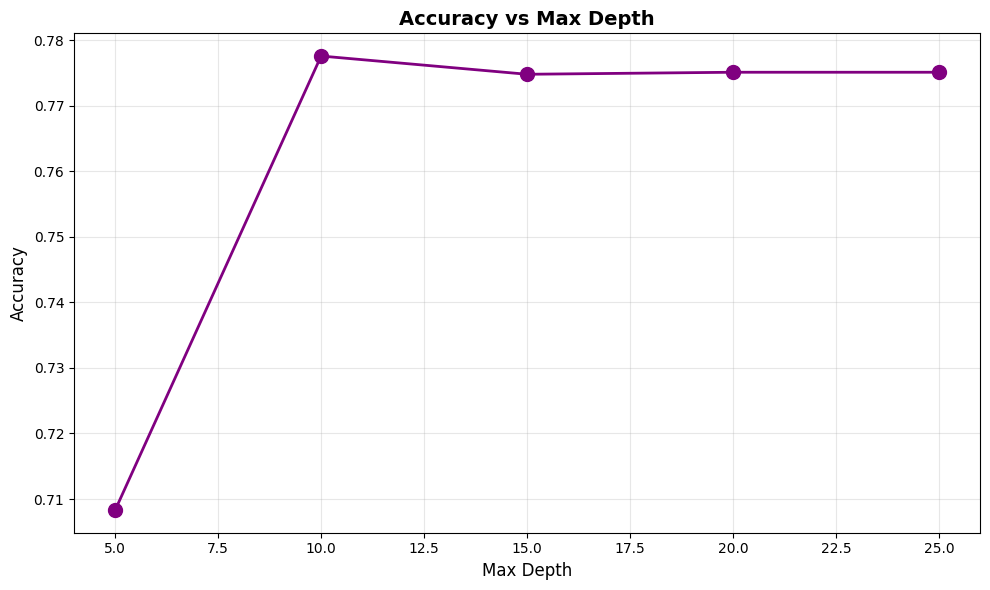

In [47]:
print("\n" + "=" * 60)
print("SKENARIO 4: PERBANDINGAN MAX DEPTH")
print("=" * 60)

max_depths = [5, 10, 15, 20, None]
depth_results = []

for max_depth in max_depths:
    dt_temp = DecisionTreeClassifier(max_depth=max_depth, **{k:v for k,v in grid_search.best_params_.items() if k != 'max_depth'}, random_state=42)
    dt_temp.fit(X_train, y_train)
    y_pred_temp = dt_temp.predict(X_test)

    acc = accuracy_score(y_test, y_pred_temp)
    depth_results.append({
        'Max Depth': str(max_depth),
        'Accuracy': acc
    })

    print(f"Max Depth {max_depth} - Accuracy: {acc:.4f}")

depth_df = pd.DataFrame(depth_results)

# Visualisasi
plt.figure(figsize=(10, 6))
depths_plot = [5, 10, 15, 20, 25]  # 25 untuk None
accs_plot = [r['Accuracy'] for r in depth_results]
plt.plot(depths_plot, accs_plot, marker='o', linestyle='-', linewidth=2, markersize=10, color='purple')
plt.xlabel('Max Depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs Max Depth', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kesimpulan dan Insight

In [48]:
print("\n" + "=" * 80)
print(" " * 25 + "RINGKASAN HASIL PENELITIAN")
print("=" * 80)

print(f"\n📊 MODEL PERFORMANCE:")
print(f"   • Best Model: Decision Tree with {grid_search.best_params_}")
print(f"   • Overall Accuracy: {accuracy_final:.4f} ({accuracy_final*100:.2f}%)")
print(f"   • Weighted F1-Score: {f1_final:.4f}")
print(f"   • Cross-Validation Mean: {cv_scores.mean():.4f}")
print(f"   • Cross-Validation Std: {cv_scores.std():.4f}")

print(f"\n🎯 PERFORMANCE PER POSITION:")
for idx, row in metrics_df.iterrows():
    print(f"   • {row['Position']}: Precision={row['Precision']:.4f}, Recall={row['Recall']:.4f}, F1={row['F1-Score']:.4f}")

print(f"\n⭐ TOP 5 MOST IMPORTANT FEATURES:")
for idx, row in feature_importance_final.head(5).iterrows():
    print(f"   {idx+1}. {row['Feature']}: {row['Importance']:.4f}")

print(f"\n✅ MODEL VALIDATION:")
print(f"   • Baseline Accuracy: {accuracy_baseline:.4f}")
print(f"   • Final Accuracy: {accuracy_final:.4f}")
print(f"   • Improvement: {(accuracy_final - accuracy_baseline)*100:.2f}%")

if cv_scores.std() < 0.05:
    print(f"   • ✓ Model is stable (CV variance < 5%)")
else:
    print(f"   • ⚠ Model might be overfitting (CV variance ≥ 5%)")

print("\n" + "=" * 80)


                         RINGKASAN HASIL PENELITIAN

📊 MODEL PERFORMANCE:
   • Best Model: Decision Tree with {'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 20}
   • Overall Accuracy: 0.7776 (77.76%)
   • Weighted F1-Score: 0.7770
   • Cross-Validation Mean: 0.7806
   • Cross-Validation Std: 0.0091

🎯 PERFORMANCE PER POSITION:
   • DF: Precision=0.8681, Recall=0.8441, F1=0.8559
   • FW: Precision=0.7581, Recall=0.6516, F1=0.7008
   • GK: Precision=0.7260, Recall=0.8760, F1=0.7940
   • MF: Precision=0.7269, Recall=0.7486, F1=0.7376

⭐ TOP 5 MOST IMPORTANT FEATURES:
   9. attack_defense_ratio: 0.5051
   1. PAC: 0.1164
   5. DEF: 0.1149
   6. PHY: 0.0933
   3. PAS: 0.0715

✅ MODEL VALIDATION:
   • Baseline Accuracy: 0.7532
   • Final Accuracy: 0.7776
   • Improvement: 2.44%
   • ✓ Model is stable (CV variance < 5%)



# Training Model

**Save dan Load Model**

In [49]:
import joblib

# Save model
joblib.dump(best_dt, 'decision_tree_fc25_model.pkl')
print("✓ Model saved as 'decision_tree_fc25_model.pkl'")

✓ Model saved as 'decision_tree_fc25_model.pkl'


In [50]:
# Save scaler
joblib.dump(scaler, 'scaler.pkl')
print("✓ Scaler saved as 'scaler.pkl'")

✓ Scaler saved as 'scaler.pkl'


In [55]:
# Load model (untuk penggunaan di masa depan)
loaded_model = joblib.load('decision_tree_fc25_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# Create and save a new scaler specifically for selected_features
# This ensures the new player data is scaled consistently with the model's training data
feature_set_scaler = MinMaxScaler()
feature_set_scaler.fit(X_train)
joblib.dump(feature_set_scaler, 'feature_set_scaler.pkl')
print("✓ Feature set scaler saved as 'feature_set_scaler.pkl'")

✓ Feature set scaler saved as 'feature_set_scaler.pkl'


**(Training) Prediksi untuk Data Baru**

In [58]:
# Contoh prediksi untuk pemain baru
new_player = pd.DataFrame({
    'PAC': [68],
    'SHO': [49],
    'PAS': [60],
    'DRI': [67],
    'DEF': [31],
    'PHY': [56],
    'attack_score': [64],
    'defense_score': [34],
    'attack_defense_ratio': [1]
})

# Load the specific scaler for the selected features
# This assumes 'feature_set_scaler.pkl' was correctly created and saved during preprocessing
loaded_feature_set_scaler = joblib.load('feature_set_scaler.pkl')

# Scaling using the feature-specific scaler
new_player_scaled = loaded_feature_set_scaler.transform(new_player)

# Prediksi
prediction = best_dt.predict(new_player_scaled)
prediction_proba = best_dt.predict_proba(new_player_scaled)

print(f"Predicted Position: {prediction[0]}")
print(f"Prediction Probabilities:")
for idx, pos in enumerate(best_dt.classes_):
    print(f"  {pos}: {prediction_proba[0][idx]:.4f}")

Predicted Position: MF
Prediction Probabilities:
  DF: 0.0909
  FW: 0.0000
  GK: 0.2727
  MF: 0.6364
